In [8]:
%pip install --user --upgrade numpy scipy

     |████████████████████████████████| 19.5 MB 11.4 MB/s            
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import f_oneway


files = {
    "n1": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n1.csv",
    "n2": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n2.csv",
    "n3": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n3.csv",
    "n4": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n4.csv",
    "n5": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n5.csv",
    "n6": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n6.csv",
    "n7": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n7.csv",
    "n8": "/home/mengelsl/MA-bench-framework/benchmark/spmv_deep_analysis/n8.csv",
}
#CSV format:
#Matrix,Cores,Run,Type,Iteration,Runtime,Gflops
all_data = []
for name, path in files.items():
    df = pd.read_csv(path,index_col=False)
    df['Environment'] = name 
    all_data.append(df)

df = pd.concat(all_data, ignore_index=True)
df_iter=df[df['Type'] == 'ITER']
df_io=df[df['Type'] == 'IO_LOAD']

Anzahl Runs pro Environment: {'host1': 5, 'host2': 5, 'host3': 5, 'host4': 5, 'host5': 5, 'host6': 5, 'host7': 5, 'host8': 5}


/tmp/ipykernel_2031411/183147520.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Environment', y='mean_Gflops', data=run_means, palette="Set3")


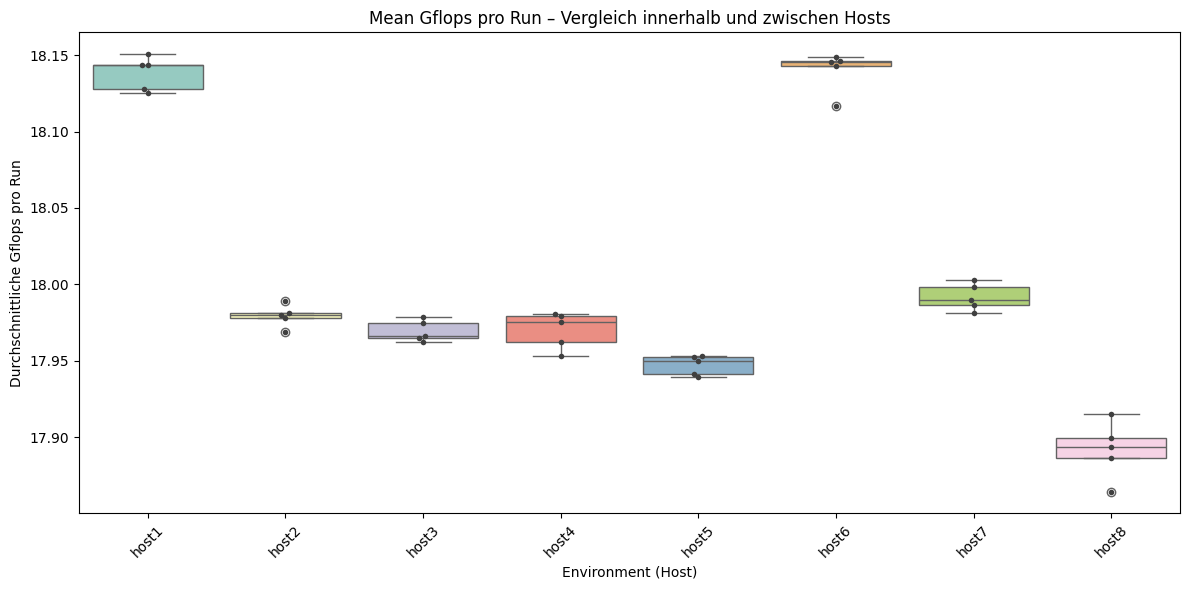


=== VARIANZEN ===
Durchschnittliche Varianz INNERHALB einer File (Run-to-Run): 0.0001
Varianz ZWISCHEN den Files (Host-Mittelwerte):               0.0079
Verhältnis (zwischen / innerhalb):                          62.61

=== ANOVA-ERGEBNIS ===
F-Statistik:      313.0311
p-Wert:           0.000000
→ SIGNIFIKANTER Unterschied zwischen Hosts (p < 0.05)!
   Die Runs innerhalb einer File hängen stark zusammen.
   Du solltest die Environment (Host) als Faktor berücksichtigen.

Intra-Class Correlation (ICC): 0.9856  (je höher, desto stärker hängen Runs in einer File zusammen)


In [2]:
# =============================================
# ANALYSE: Varianz innerhalb der Runs pro File vs. zwischen Files
# =============================================

# Schritt 1: Aggregation auf Run-Level
# Für jeden Run (5 pro Host) berechnen wir den Mittelwert der Gflops über alle 500 Iterationen.
# (Falls mehrere Matrices/Cores vorhanden sind, wird über alles gemittelt – das ist fair, weil das Bash-Skript identisch ist)
from matplotlib import pyplot as plt


run_means = (
    df_iter
    .groupby(['Environment', 'Run'])['Gflops']
    .mean()
    .reset_index(name='mean_Gflops')
)

print("Anzahl Runs pro Environment:", run_means.groupby('Environment')['Run'].count().to_dict())

# Schritt 2: Visualisierung – Boxplot der Run-Mittelwerte pro Host
plt.figure(figsize=(12, 6))
sns.boxplot(x='Environment', y='mean_Gflops', data=run_means, palette="Set3")
sns.swarmplot(x='Environment', y='mean_Gflops', data=run_means, color=".25", size=4)
plt.title('Mean Gflops pro Run – Vergleich innerhalb und zwischen Hosts')
plt.xlabel('Environment (Host)')
plt.ylabel('Durchschnittliche Gflops pro Run')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Schritt 3: Explizite Varianz-Berechnung
# - Varianz INNERHALB einer File (Run-to-Run Varianz pro Host)
# - Varianz ZWISCHEN den Files (Varianz der Host-Mittelwerte)

# Gruppen bilden
groups = []
env_means = []
within_vars = []

for env, group in run_means.groupby('Environment'):
    run_values = group['mean_Gflops'].values
    groups.append(run_values)
    env_means.append(np.mean(run_values))
    within_vars.append(np.var(run_values, ddof=1))  # Sample-Varianz

avg_within_variance = np.mean(within_vars)           # Durchschnittliche Varianz innerhalb der Files
between_variance = np.var(env_means, ddof=1)         # Varianz zwischen den Host-Mittelwerten

print("\n=== VARIANZEN ===")
print(f"Durchschnittliche Varianz INNERHALB einer File (Run-to-Run): {avg_within_variance:.4f}")
print(f"Varianz ZWISCHEN den Files (Host-Mittelwerte):               {between_variance:.4f}")
print(f"Verhältnis (zwischen / innerhalb):                          {between_variance / avg_within_variance:.2f}")

# Schritt 4: Statistischer Test – One-Way ANOVA
# Testet, ob die Mittelwerte der Runs zwischen den Hosts signifikant unterschiedlich sind.
# → Wenn p < 0.05: Runs in einer File "hängen zusammen" (Host-Effekt), du kannst sie NICHT einfach über alle Files poolen.
f_stat, p_value = f_oneway(*groups)

print("\n=== ANOVA-ERGEBNIS ===")
print(f"F-Statistik:      {f_stat:.4f}")
print(f"p-Wert:           {p_value:.6f}")

if p_value < 0.05:
    print("→ SIGNIFIKANTER Unterschied zwischen Hosts (p < 0.05)!")
    print("   Die Runs innerhalb einer File hängen stark zusammen.")
    print("   Du solltest die Environment (Host) als Faktor berücksichtigen.")
else:
    print("→ KEIN signifikanter Unterschied zwischen Hosts (p >= 0.05).")
    print("   Die Runs können individuell betrachtet werden – unabhängig von der File.")

# Bonus: Intra-Class Correlation (ICC) als Maß, wie stark die Runs pro Host zusammenhängen
# (0 = keine Ähnlichkeit, 1 = perfekte Ähnlichkeit innerhalb Host)
grand_mean = np.mean(env_means)
ss_between = 5 * np.sum((np.array(env_means) - grand_mean)**2)  # n=5 Runs pro Host
ss_within = sum(np.sum((g - np.mean(g))**2) for g in groups)
icc = ss_between / (ss_between + ss_within)
print(f"\nIntra-Class Correlation (ICC): {icc:.4f}  (je höher, desto stärker hängen Runs in einer File zusammen)")

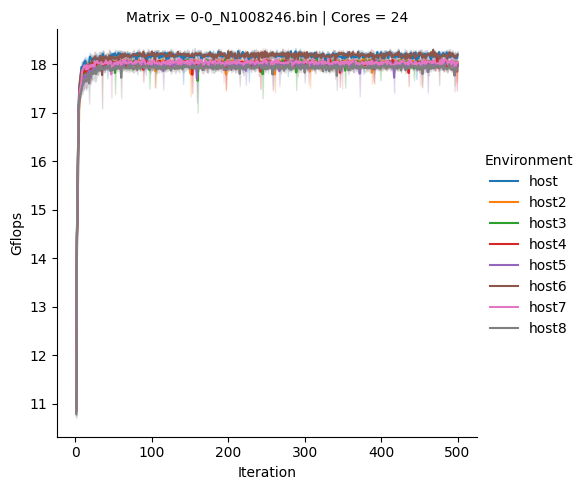

In [15]:
g = sns.relplot(
    data=df_iter, 
    x='Iteration', 
    y='Gflops', 
    hue='Environment',     
    col='Cores',      
	row='Matrix',       
    kind='line', 
    facet_kws={'sharey': False}, 
)

in jedem host run -> 5 runs , darin pro iter den std nehmen

In [25]:
for file in files.keys():
	df_single = df_iter[df_iter['Environment'] == file]
	df_std = df_single.groupby(['Matrix', 'Cores','Iteration'])['Gflops'].std().reset_index(name='Gflops_std')
	mean = df_std["Gflops_std"].mean()
	print(f"{file}: {mean}")


host1: 0.08363225254627313
host2: 0.08001127720328481
host3: 0.08064715701800575
host4: 0.0785511465783191
host5: 0.0790866060978347
host6: 0.08532432040077996
host7: 0.08065619325027629
host8: 0.07701019726611377
